2.1
1）向量点积 a・b
a・b = a₁b₁ + a₂b₂ + a₃b₃= 2×1 + (−1)×4 + 3×(−2)= 2 − 4 − 6= −8
2）矩阵乘法 A×B
第一行第一列：1×2 + 0×0 + 2×3 = 2 + 0 + 6 = 8第一行第二列：1×1 + 0×(−1) + 2×2 = 1 + 0 + 4 = 5第二行第一列：−1×2 + 3×0 + 1×3 = −2 + 0 + 3 = 1第二行第二列：−1×1 + 3×(−1) + 1×2 = −1 − 3 + 2 = −2
A×B = [[8, 5],[1, −2]]
3）a 的 Frobenius 范数
||a||_F = √(a₁² + a₂² + a₃²)= √(2² + (−1)² + 3²)= √(4 + 1 + 9)= √14

In [1]:
2.2
import numpy as np

# 1. 3×4 标准正态
X = np.random.randn(3, 4)

# 2. 4×2 全1矩阵
Y = np.ones((4, 2))

# 3. 矩阵乘法
Z = X @ Y

# 4. 输出指定位置
print("Z[0,1] =", Z[0, 1])
print("Z 第2行 =", Z[1])

# 5. Frobenius 范数
print("Z 的 F 范数 =", np.linalg.norm(Z))

Z[0,1] = 2.483409263457155
Z 第2行 = [-0.4952828 -0.4952828]
Z 的 F 范数 = 4.063863614425549


3.1 贝叶斯公式
设：A = 患病¬A = 未患病B = 检测阳性
已知：P (A) = 0.001P (¬A) = 0.999P (B|A) = 0.99P (B|¬A) = 0.02
求：P (A|B)
推导过程：P(A|B) = [P(B|A) × P(A)] / P(B)
全概率：P (B) = P (B|A) P (A) + P (B|¬A) P (¬A)
代入：P (A|B) = (0.99×0.001) / (0.99×0.001 + 0.02×0.999)= 0.00099 / 0.02097≈ 0.0472（4.72%）

d:\anaconda\envs\text\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\text\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\text\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26497 (\N{CJK UNIFIED IDEOGRAPH-6781}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\text\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38480 (\N{CJK UNIFIED IDEOGRAPH-9650}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\text\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  fig.canvas

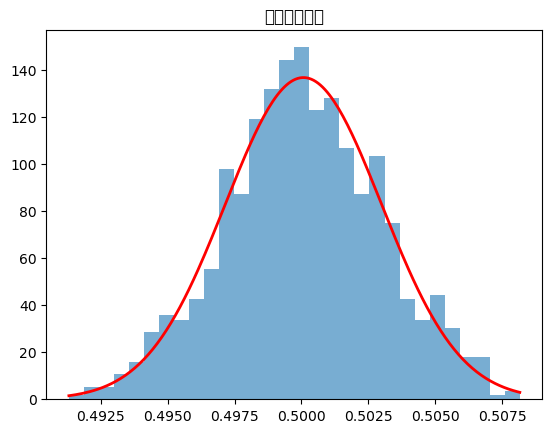

均值方差 = 8.522040222817443e-06


In [2]:
3.2
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

n = 10000
m = 1000
means = [np.random.rand(n).mean() for _ in range(m)]

plt.hist(means, bins=30, density=True, alpha=0.6)
mu, std = np.mean(means), np.std(means)
x = np.linspace(min(means), max(means), 200)
plt.plot(x, norm.pdf(x, mu, std), 'r-', lw=2)
plt.title("中心极限定理")
plt.show()

print("均值方差 =", np.var(means))

4.1 偏导数与梯度
已知：z = (w₁x₁ + w₂x₂ − y)²x₁=2，x₂=1，y=3
1）求偏导表达式
令 u = w₁x₁ + w₂x₂ − yz = u²
链式法则：∂z/∂w₁ = 2u・∂u/∂w₁ = 2・(w₁x₁+w₂x₂−y)・x₁∂z/∂w₂ = 2u・∂u/∂w₂ = 2・(w₁x₁+w₂x₂−y)・x₂
即：∂z/∂w₁ = 2x₁(w₁x₁ + w₂x₂ − y)∂z/∂w₂ = 2x₂(w₁x₁ + w₂x₂ − y)
2）代入 w₁=0.5，w₂=1
u = 0.5×2 + 1×1 − 3 = 1 + 1 − 3 = −1
∂z/∂w₁ = 2×2×(−1) = −4∂z/∂w₂ = 2×1×(−1) = −2

In [4]:
import torch

x, w1, w2 = 2, 1.5, 0.5
a = x * w1
b = a + w2
L = b ** 2
print("前向 L =", L)  # 这里直接打印，不用 .item()

# 手动梯度
dL_db = 2 * b
dL_dw1 = dL_db * x
dL_dw2 = dL_db * 1
print("手动 dw1 =", dL_dw1, " dw2 =", dL_dw2)

# 自动微分验证
w1t = torch.tensor(1.5, requires_grad=True)
w2t = torch.tensor(0.5, requires_grad=True)
Lt = (x * w1t + w2t) ** 2
Lt.backward()
print("自动 dw1 =", w1t.grad.item(), " dw2 =", w2t.grad.item())

前向 L = 12.25
手动 dw1 = 14.0  dw2 = 7.0
自动 dw1 = 14.0  dw2 = 7.0


5.1 线性回归梯度推导
损失：L = (1/n)・Σ (yᵢ − (w xᵢ + b))²
对 w 求导：
∂L/∂w = (1/n) · Σ 2·(yᵢ −w xᵢ −b)·(−xᵢ)= −(2/n) · Σ xᵢ (yᵢ − w xᵢ − b)
对 b 求导：
∂L/∂b = (1/n) · Σ 2·(yᵢ −w xᵢ −b)·(−1)= −(2/n) · Σ (yᵢ − w xᵢ − b)

In [5]:
5.2
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

data = load_digits()
X, y = data.data / 16.0, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

onehot = OneHotEncoder(sparse_output=False)
y_train_oh = onehot.fit_transform(y_train.reshape(-1, 1))

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy(pred, true):
    return -np.mean(np.sum(true * np.log(pred + 1e-8), axis=1))

W = np.random.randn(64, 10) * 0.01
b = np.zeros(10)
lr = 0.1
epochs = 50
bs = 32

for epoch in range(epochs):
    for i in range(0, len(X_train), bs):
        xb = X_train[i:i+bs]
        yb = y_train_oh[i:i+bs]
        pred = softmax(xb @ W + b)
        dz = (pred - yb) / len(xb)
        W -= lr * (xb.T @ dz)
        b -= lr * np.sum(dz, axis=0)

pred_test = softmax(X_test @ W + b)
acc = np.mean(np.argmax(pred_test, axis=1) == y_test)
print("测试集准确率 =", acc)

测试集准确率 = 0.9444444444444444


6.1 正态分布极大似然估计
xᵢ ~ N(μ, σ²)
1）似然函数
L(μ,σ²) = ∏ [ 1/√(2πσ²) · exp( −(xᵢ−μ)²/(2σ²) ) ]
2）μ 的极大似然估计
取对数：lnL = −(n/2) ln (2π) − (n/2) lnσ² − (1/(2σ²))・Σ(xᵢ−μ)²
对 μ 求导并令为 0：d (lnL)/dμ = (1/σ²)・Σ(xᵢ−μ) = 0得：Σ(xᵢ−μ)=0 → μ̂ = (1/n)Σxᵢ
3）σ² 的极大似然估计
对 σ² 求导并令为 0：d (lnL)/dσ² = −n/(2σ²) + (1/(2σ⁴))・Σ(xᵢ−μ̂)² = 0得：σ̂² = (1/n)・Σ(xᵢ − μ̂)²


测试准确率 = 1.0


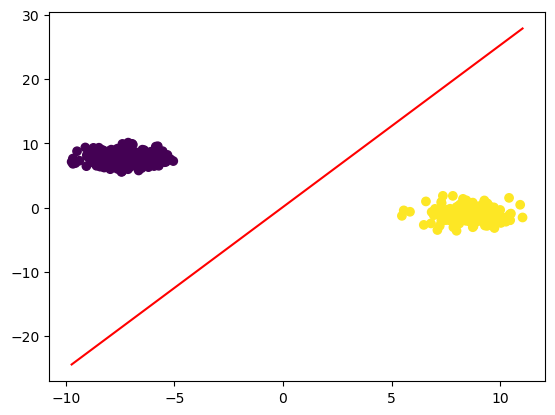

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

X, y = make_blobs(n_samples=400, centers=2, n_features=2, random_state=2025)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=100)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def bce(pred, true):
    return -np.mean(true * np.log(pred + 1e-8) + (1 - true) * np.log(1 - pred + 1e-8))

w = np.zeros(2)
b = 0.0
lr = 0.1
iters = 1000

for _ in range(iters):
    z = X_train @ w + b
    pred = sigmoid(z)
    dz = pred - y_train
    w -= lr * (X_train.T @ dz) / len(X_train)
    b -= lr * np.mean(dz)

pred_test = (sigmoid(X_test @ w + b) > 0.5).astype(int)
acc = np.mean(pred_test == y_test)
print("测试准确率 =", acc)

plt.scatter(X[:, 0], X[:, 1], c=y)
x1 = np.array([X[:, 0].min(), X[:, 0].max()])
x2 = -(w[0] * x1 + b) / w[1]
plt.plot(x1, x2, 'r-')
plt.show()